# CAS KAGGLE: `Detection of Pistachio Types By Classifier Models`


## INTRODUCCIÓ

## BASE DE DADES

En el nostre Cas Kaggle hem triat una base de dades de pistatxos, que a partir atributs extrets d'imatges processades té l'objectiu de predir de quin tipus de pistatxo es tracta: `Kirmizi` o  bé `Siit`.

https://www.kaggle.com/datasets/amirhosseinmirzaie/pistachio-types-detection/data

In [120]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import math
from sklearn.preprocessing import LabelEncoder
from IPython.display import Image

In [121]:
df = pd.read_csv("./archive/pistachio.csv")


In [122]:
df.describe(include="all")

,AREA,PERIMETER,MAJOR_AXIS,MINOR_AXIS,ECCENTRICITY,EQDIASQ,SOLIDITY,CONVEX_AREA,EXTENT,ASPECT_RATIO,ROUNDNESS,COMPACTNESS,SHAPEFACTOR_1,SHAPEFACTOR_2,SHAPEFACTOR_3,SHAPEFACTOR_4,Class
count,1718.000000,1718.000000,1718.000000,1718.000000,1718.000000,1718.000000,1718.000000,1718.000000,1718.000000,1718.000000,1718.000000,1718.000000,1718.000000,1718.000000,1718.000000,1718.000000,1718
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Kirmizi_Pistachio
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,998
mean,79871.952852,1421.797588,446.206444,238.193128,0.840347,317.790000,0.940103,84947.671129,0.716055,1.899342,0.570831,0.712841,0.005704,0.003017,0.510097,0.955185,NaN
std,12968.217051,373.408835,31.885328,30.426445,0.049026,26.571699,0.050006,13081.742551,0.052534,0.241253,0.211514,0.044230,0.000810,0.000334,0.063391,0.051735,NaN
min,29808.000000,858.363000,321.425500,133.509600,0.504900,194.814600,0.588000,37935.000000,0.427200,1.158500,0.062800,0.476000,0.004000,0.002400,0.226600,0.620400,NaN
25%,71898.500000,1169.633225,426.554100,217.875475,0.817500,302.562375,0.920250,76357.750000,0.688100,1.736325,0.372325,0.682000,0.005200,0.002800,0.465125,0.944200,NaN
50%,79795.000000,1260.785500,448.453150,235.888750,0.850250,318.744650,0.953800,84973.000000,0.726100,1.899550,0.643850,0.709750,0.005600,0.003000,0.503750,0.972800,NaN
75%,88980.000000,1599.479000,467.515200,257.433625,0.875375,336.590000,0.976300,93660.750000,0.753600,2.068575,0.744450,0.741600,0.006100,0.003200,0.549975,0.986800,NaN


La nostra base de dades té els següents atributs on `int64` és un nombre enter, `float64` és un nombre decimal i `object` una cadena de text.

In [123]:
df.dtypes

AREA               int64
PERIMETER        float64
MAJOR_AXIS       float64
MINOR_AXIS       float64
ECCENTRICITY     float64
EQDIASQ          float64
SOLIDITY         float64
CONVEX_AREA        int64
EXTENT           float64
ASPECT_RATIO     float64
ROUNDNESS        float64
COMPACTNESS      float64
SHAPEFACTOR_1    float64
SHAPEFACTOR_2    float64
SHAPEFACTOR_3    float64
SHAPEFACTOR_4    float64
Class             object
dtype: object

En la següent fotografía podem observar millor a que correspon cada atribut:

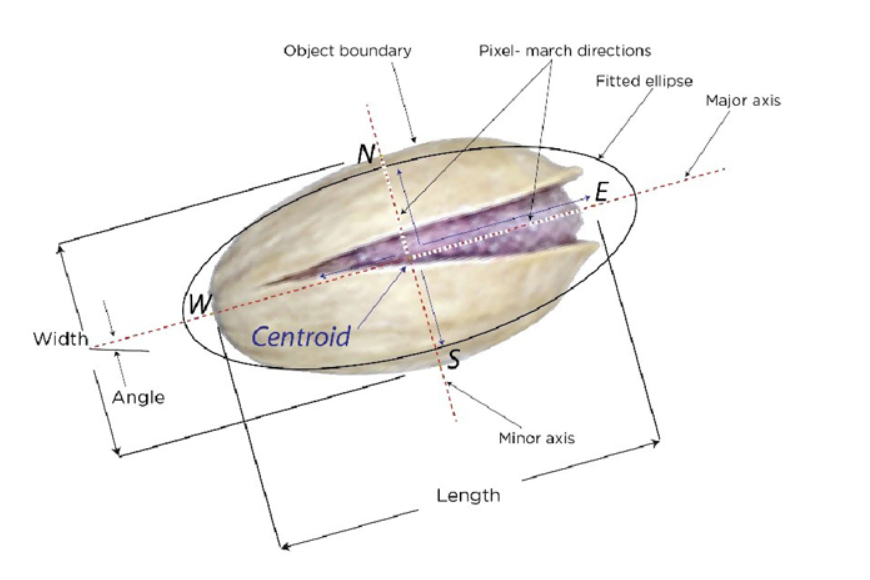

In [124]:
Image(filename='Imatges/imatge_atributs_pistatxo.png')


- `AREA`: nombre enter, l'àrea de pistatxo detectada a l'imatge.
- `PERIMETER`: nombre decimal, perímetre del pistatxo (frontera de l'imatge detectada).
- `MAJOR_AXIS`: nombre decimal, llargada de l'eix major de l'el·lipse que millor s'adapta a l'imatge del pistatxo.
- `MINOR_AXIS`: nombre decimal, llargada de l'eix menor de l'el·lipse que millor s'adapta a l'imatge del pistatxo.
- `ECCENTRICITY`: nombre decimal, excentricitat de l'el·lipse (que tan allargada està) de la regió del pistatxo ($e=\sqrt{1-\frac{b^2}{a^2}}$).
- `EQDIASQ`: nombre decimal, diàmetre del cercle que tindria la mateixa àrea que l'el·lipse del pistatxo.
- `SOLIDITY`: nombre decimal, proporció entre l'àrea real i l'àrea del polígon convex que millor envolta el pistatxo $\frac{\text{ÀREA PISTATXO}}{\text{ÀREA POLÍGON CONVEX}}$.
- `CONVEX_AREA`: nombre enter, àrea del polígon convex que millor envolta el pistatxo. 
- `EXTENT`: nombre decimal, proporció entre l'àrea real i l'àrea del rectangle que millor envolta el pistatxo ($\frac{\text{ÀREA PISTATXO}}{\text{ÀREA RECTANGLE}}$).
- `ASPECT_RATIO`: nombre decimal, proporció entre eix major i menor ($\frac{\text{EIX MAJOR}}{\text{EIX MENOR}}$).
- `ROUNDNESS`: nombre decimal, mesura que tant s'assembla la regió del pistatxo a un cercle.
- `COMPACTNESS`: nombre decimal, mesura que tant concentrada està la forma de l'objecte comparant mida i elongació.
- `SHAPEFACTOR_1`, `SHAPEFACTOR_2`, `SHAPEFACTOR_3`, `SHAPEFACTOR_4`: nombres decimals, són atributs extrets de l'àrea i perímetre de la regió del pistatxo, no hi ha molta més informació de sobre que es tracten. 

El Target és l'atribut categòric `Class`, que pot prendre dos valors `Kirmizi_Pistachio` o `Siit_Pistachio` depenent quin tipus de pistatxo sigui.

In [125]:
df['Class'].value_counts()

Class
Kirmizi_Pistachio    998
Siit_Pistachio       720
Name: count, dtype: int64

In [126]:
df.isna().sum()

AREA             0
PERIMETER        0
MAJOR_AXIS       0
MINOR_AXIS       0
ECCENTRICITY     0
EQDIASQ          0
SOLIDITY         0
CONVEX_AREA      0
EXTENT           0
ASPECT_RATIO     0
ROUNDNESS        0
COMPACTNESS      0
SHAPEFACTOR_1    0
SHAPEFACTOR_2    0
SHAPEFACTOR_3    0
SHAPEFACTOR_4    0
Class            0
dtype: int64

Veiem que no ens falten dades, totes les variables tenen tots els valors en cada mostra.

Per a poder analitzar les dades hem decidit agrupar totes les funcions que anem a utilitzar en una sola classe.

In [127]:
class DatasetAnalyzer:

    def __init__(self, df, target="Class"):
        """
        Inicialitza el DatasetAnalyzer.

        df: DataFrame d'entrada
        target: Nom de la variable objectiu
        """
        self.df = df.copy()
        self.target = target
        self.encoder = None
        self.labels = None

    def get_numeric_columns(self):
        """
        Retorna una llista amb totes les columnes numèriques del DataFrame.
        """
        return self.df.select_dtypes(include='number').columns.tolist()

    def get_class_values(self):
        """
        Retorna els valors únics de la variable objectiu (classes).
        """
        return self.df[self.target].unique()

    def encode_target(self):
        """
        Converteix la variable objectiu a valors numèrics amb LabelEncoder.
        Retorna un diccionari que mapeja ID: nom original de la classe.
        """
        if not np.issubdtype(self.df[self.target].dtype, np.number):
            self.encoder = LabelEncoder()
            self.df[self.target] = self.encoder.fit_transform(self.df[self.target])
            self.labels = {
                int(k): v for k, v in
                zip(self.encoder.transform(self.encoder.classes_), self.encoder.classes_)
            }
        else:
            self.labels = None
        return self.labels
    
    def decode_target(self):
        """
        Torna la variable objectiu a les seves classes originals (no codificades).
        Només funciona si prèviament s'ha fet encode_target().
        """
        if self.encoder is None:
            return None
        
        decoded = self.encoder.inverse_transform(self.df[self.target])
        self.df[self.target] = decoded
        return self.df[self.target].unique()

    def plot_histograms(self):
        """
        Genera un histograma per a cada variable del DataFrame.
        """
        cols = self.df.columns
        n_cols = len(cols)

        total_plots = n_cols
        rows = math.ceil(total_plots / 3)

        plt.figure(figsize=(18, 4 * rows))
        colors = sns.color_palette("Set2", n_cols)

        for i, col in enumerate(cols, 1):
            plt.subplot(rows, 3, i)
            plt.hist(self.df[col], bins=30, edgecolor='black', color=colors[i-1])
            plt.title(col)
            plt.grid(alpha=0.3)

        plt.tight_layout()
        plt.show()

    def plot_histograms_by_class(self):
        """
        Mostra histogrames apilats per classe per a cada variable numèrica.
        """
        self.encode_target()
        numeric_cols = self.get_numeric_columns()
        n_numeric = len(numeric_cols)

        rows = math.ceil(n_numeric / 3)
        plt.figure(figsize=(18, 5 * rows))

        for i, col in enumerate(numeric_cols, 1):
            plt.subplot(rows, 3, i)
            sns.histplot(
                data=self.df, x=col, hue=self.target,
                multiple='stack', palette='Set1',
                edgecolor='black', bins=30
            )
            plt.title(col)
            plt.grid(alpha=0.3)

        plt.tight_layout()
        plt.show()

    def plot_separate_histograms_by_class(self):
        """
        Crea dos histogrames separats per cada variable numèrica:
        un per cada classe, amb l'eix X igualat per comparar formes.
        """
        self.encode_target()
        numeric_cols = self.get_numeric_columns()
        classes = self.get_class_values()
        n_numeric = len(numeric_cols)

        rows = math.ceil(n_numeric / 2)
        fig, axes = plt.subplots(rows, 4, figsize=(24, 5 * rows))
        axes = axes.flatten()

        for i, col in enumerate(numeric_cols):
            range_val = self.df[col].max() - self.df[col].min()
            offset = range_val * 0.05
            min_val = self.df[col].min() - offset
            max_val = self.df[col].max() + offset

            for j, cl in enumerate(classes):
                ax = axes[i*2 + j]
                data = self.df[self.df[self.target] == cl][col]

                ax.hist(data, bins=20, edgecolor='black',
                        alpha=0.7, color=f'C{j}')
                ax.set_title(f'{col} - Class: {cl}')
                ax.set_xlabel(col)
                ax.set_ylabel('Count')
                ax.set_xlim(min_val, max_val)
                ax.grid(alpha=0.3)

        for k in range(len(numeric_cols)*2, len(axes)):
            axes[k].axis('off')

        plt.tight_layout()
        plt.show()
        
    def plot_boxplots(self):
        """
        Mostra boxplots de cada variable numèrica dividits per classes.
        """
        self.decode_target()
        numeric_cols = self.get_numeric_columns()
        plt.figure(figsize=(18, 5 * math.ceil(len(numeric_cols) / 3)))

        for i, col in enumerate(numeric_cols, 1):
            plt.subplot(math.ceil(len(numeric_cols) / 3), 3, i)
            sns.boxplot(data=self.df, x=self.target, y=col, hue=self.target, palette="Set2", dodge=False)
            plt.title(f'Boxplot de {col} segons {self.target}')
            plt.grid(alpha=0.3)

        plt.tight_layout()
        plt.show()

    def plot_correlation_matrix(self):
        """
        Genera un mapa de calor de la matriu de correlació de variables numèriques.
        """
        plt.figure(figsize=(12, 10))
        corr_matrix = self.df.corr(numeric_only=True)
        sns.heatmap(corr_matrix, annot=True)
        plt.tight_layout()
        plt.show()

    def plot_corr_with_target(self):
        """
        Calcula i mostra la correlació de cada variable numèrica amb la variable objectiu.
        """
        self.encode_target()
        corr_with_target = self.df.corr(numeric_only=True)[self.target].abs().drop(self.target)
        corr_with_target = corr_with_target.sort_values(ascending=False)

        plt.figure(figsize=(12, 6))
        sns.barplot(
            x=corr_with_target.index,
            y=corr_with_target.values,
            palette='viridis'
        )
        plt.title(f'Correlació amb {self.target}')
        plt.xlabel('Variables')
        plt.ylabel('Correlació')
        plt.xticks(rotation=90)
        plt.tight_layout()
        plt.show()

    def drop_highly_correlated(self, threshold=0.8):
        """
        Elimina variables molt correlacionades entre elles.
        Manté la variable més útil (la que correlaciona més amb la target).
        Retorna la llista de variables eliminades.
        """
        self.encode_target()
        corr_matrix = self.df.corr(numeric_only=True).abs()
        upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

        to_drop = set()

        for col in upper_tri.columns:
            for row in upper_tri.index:
                corr_value = upper_tri.loc[row, col]
                if corr_value > threshold:
                    corr_row_target = abs(self.df[row].corr(self.df[self.target]))
                    corr_col_target = abs(self.df[col].corr(self.df[self.target]))

                    if corr_row_target > corr_col_target:
                        to_drop.add(col)
                    else:
                        to_drop.add(row)

        self.df = self.df.drop(columns=list(to_drop))
        return list(to_drop)


In [128]:
analyzer  = DatasetAnalyzer(df, target="Class")

In [ ]:
numeric_cols = analyzer.get_numeric_columns()
print("Columnes numèriques:", numeric_cols)

Columnes numèriques: ['AREA', 'PERIMETER', 'MAJOR_AXIS', 'MINOR_AXIS', 'ECCENTRICITY', 'EQDIASQ', 'SOLIDITY', 'CONVEX_AREA', 'EXTENT', 'ASPECT_RATIO', 'ROUNDNESS', 'COMPACTNESS', 'SHAPEFACTOR_1', 'SHAPEFACTOR_2', 'SHAPEFACTOR_3', 'SHAPEFACTOR_4']


In [ ]:
class_values = analyzer.get_class_values()
print("Classes:", class_values)

Classes: ['Kirmizi_Pistachio' 'Siit_Pistachio']


Ara estudiem la distribució de les dades amb els següents gràfics.

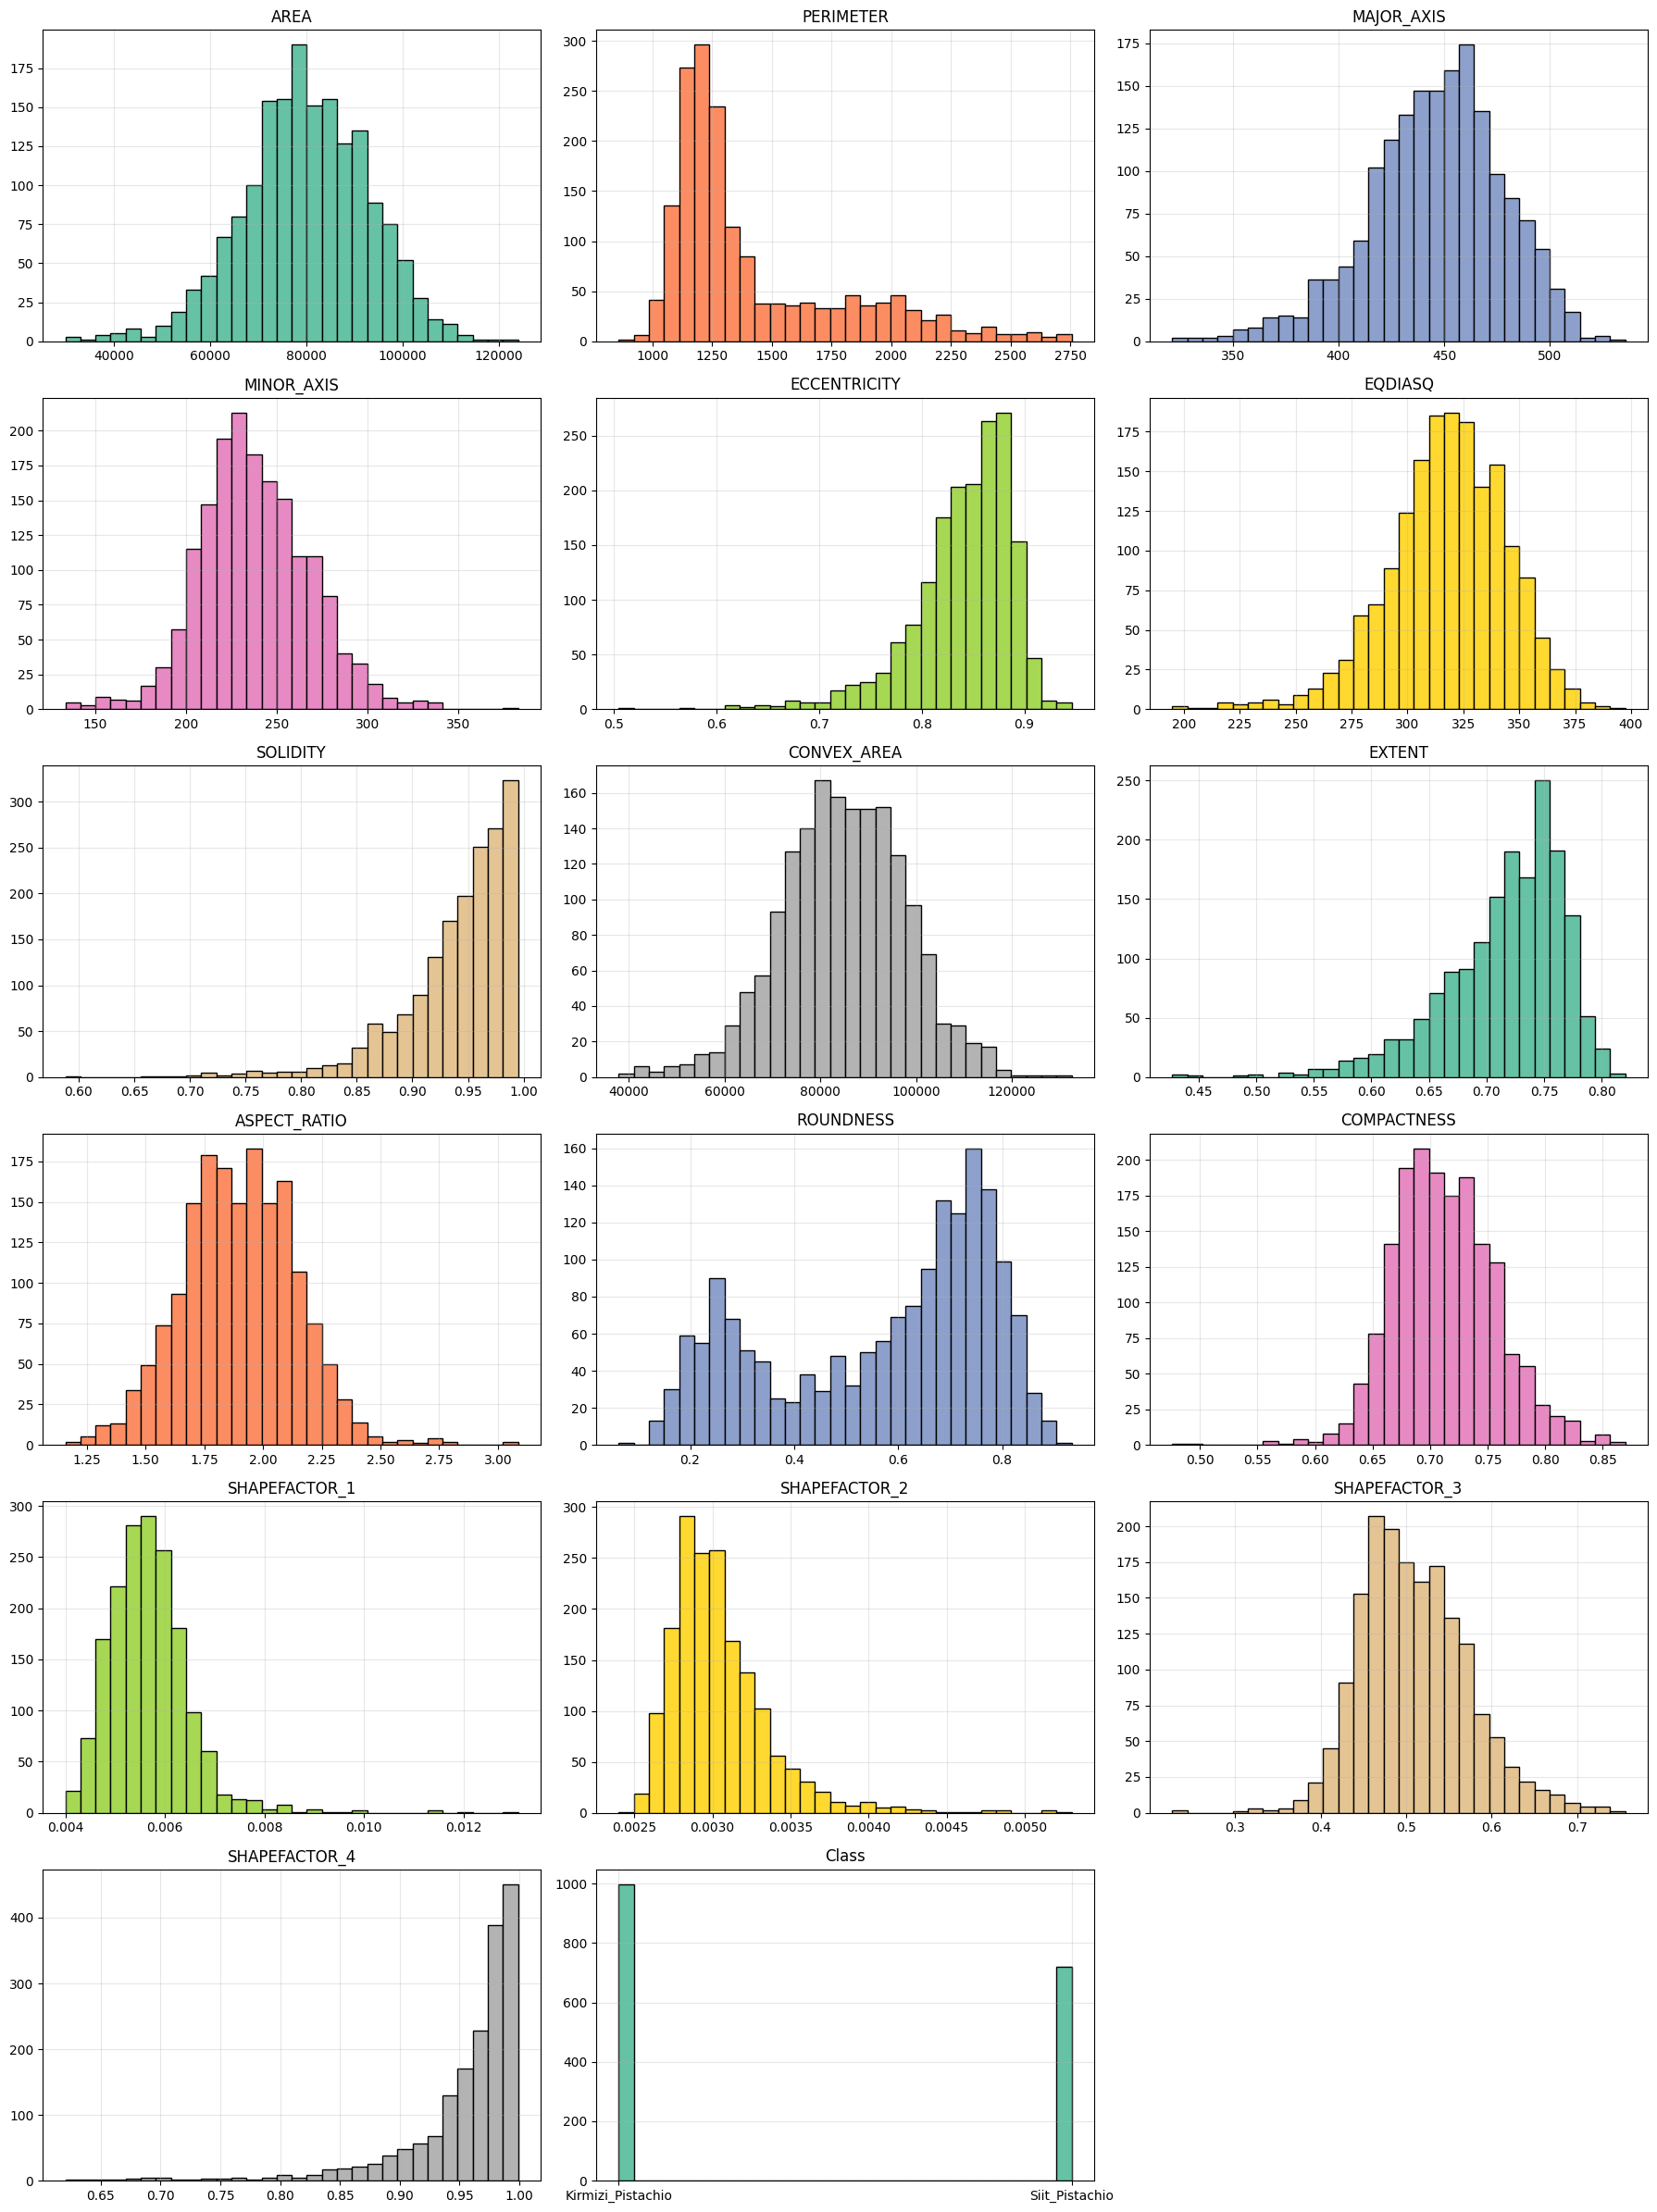

In [132]:
analyzer.plot_histograms()

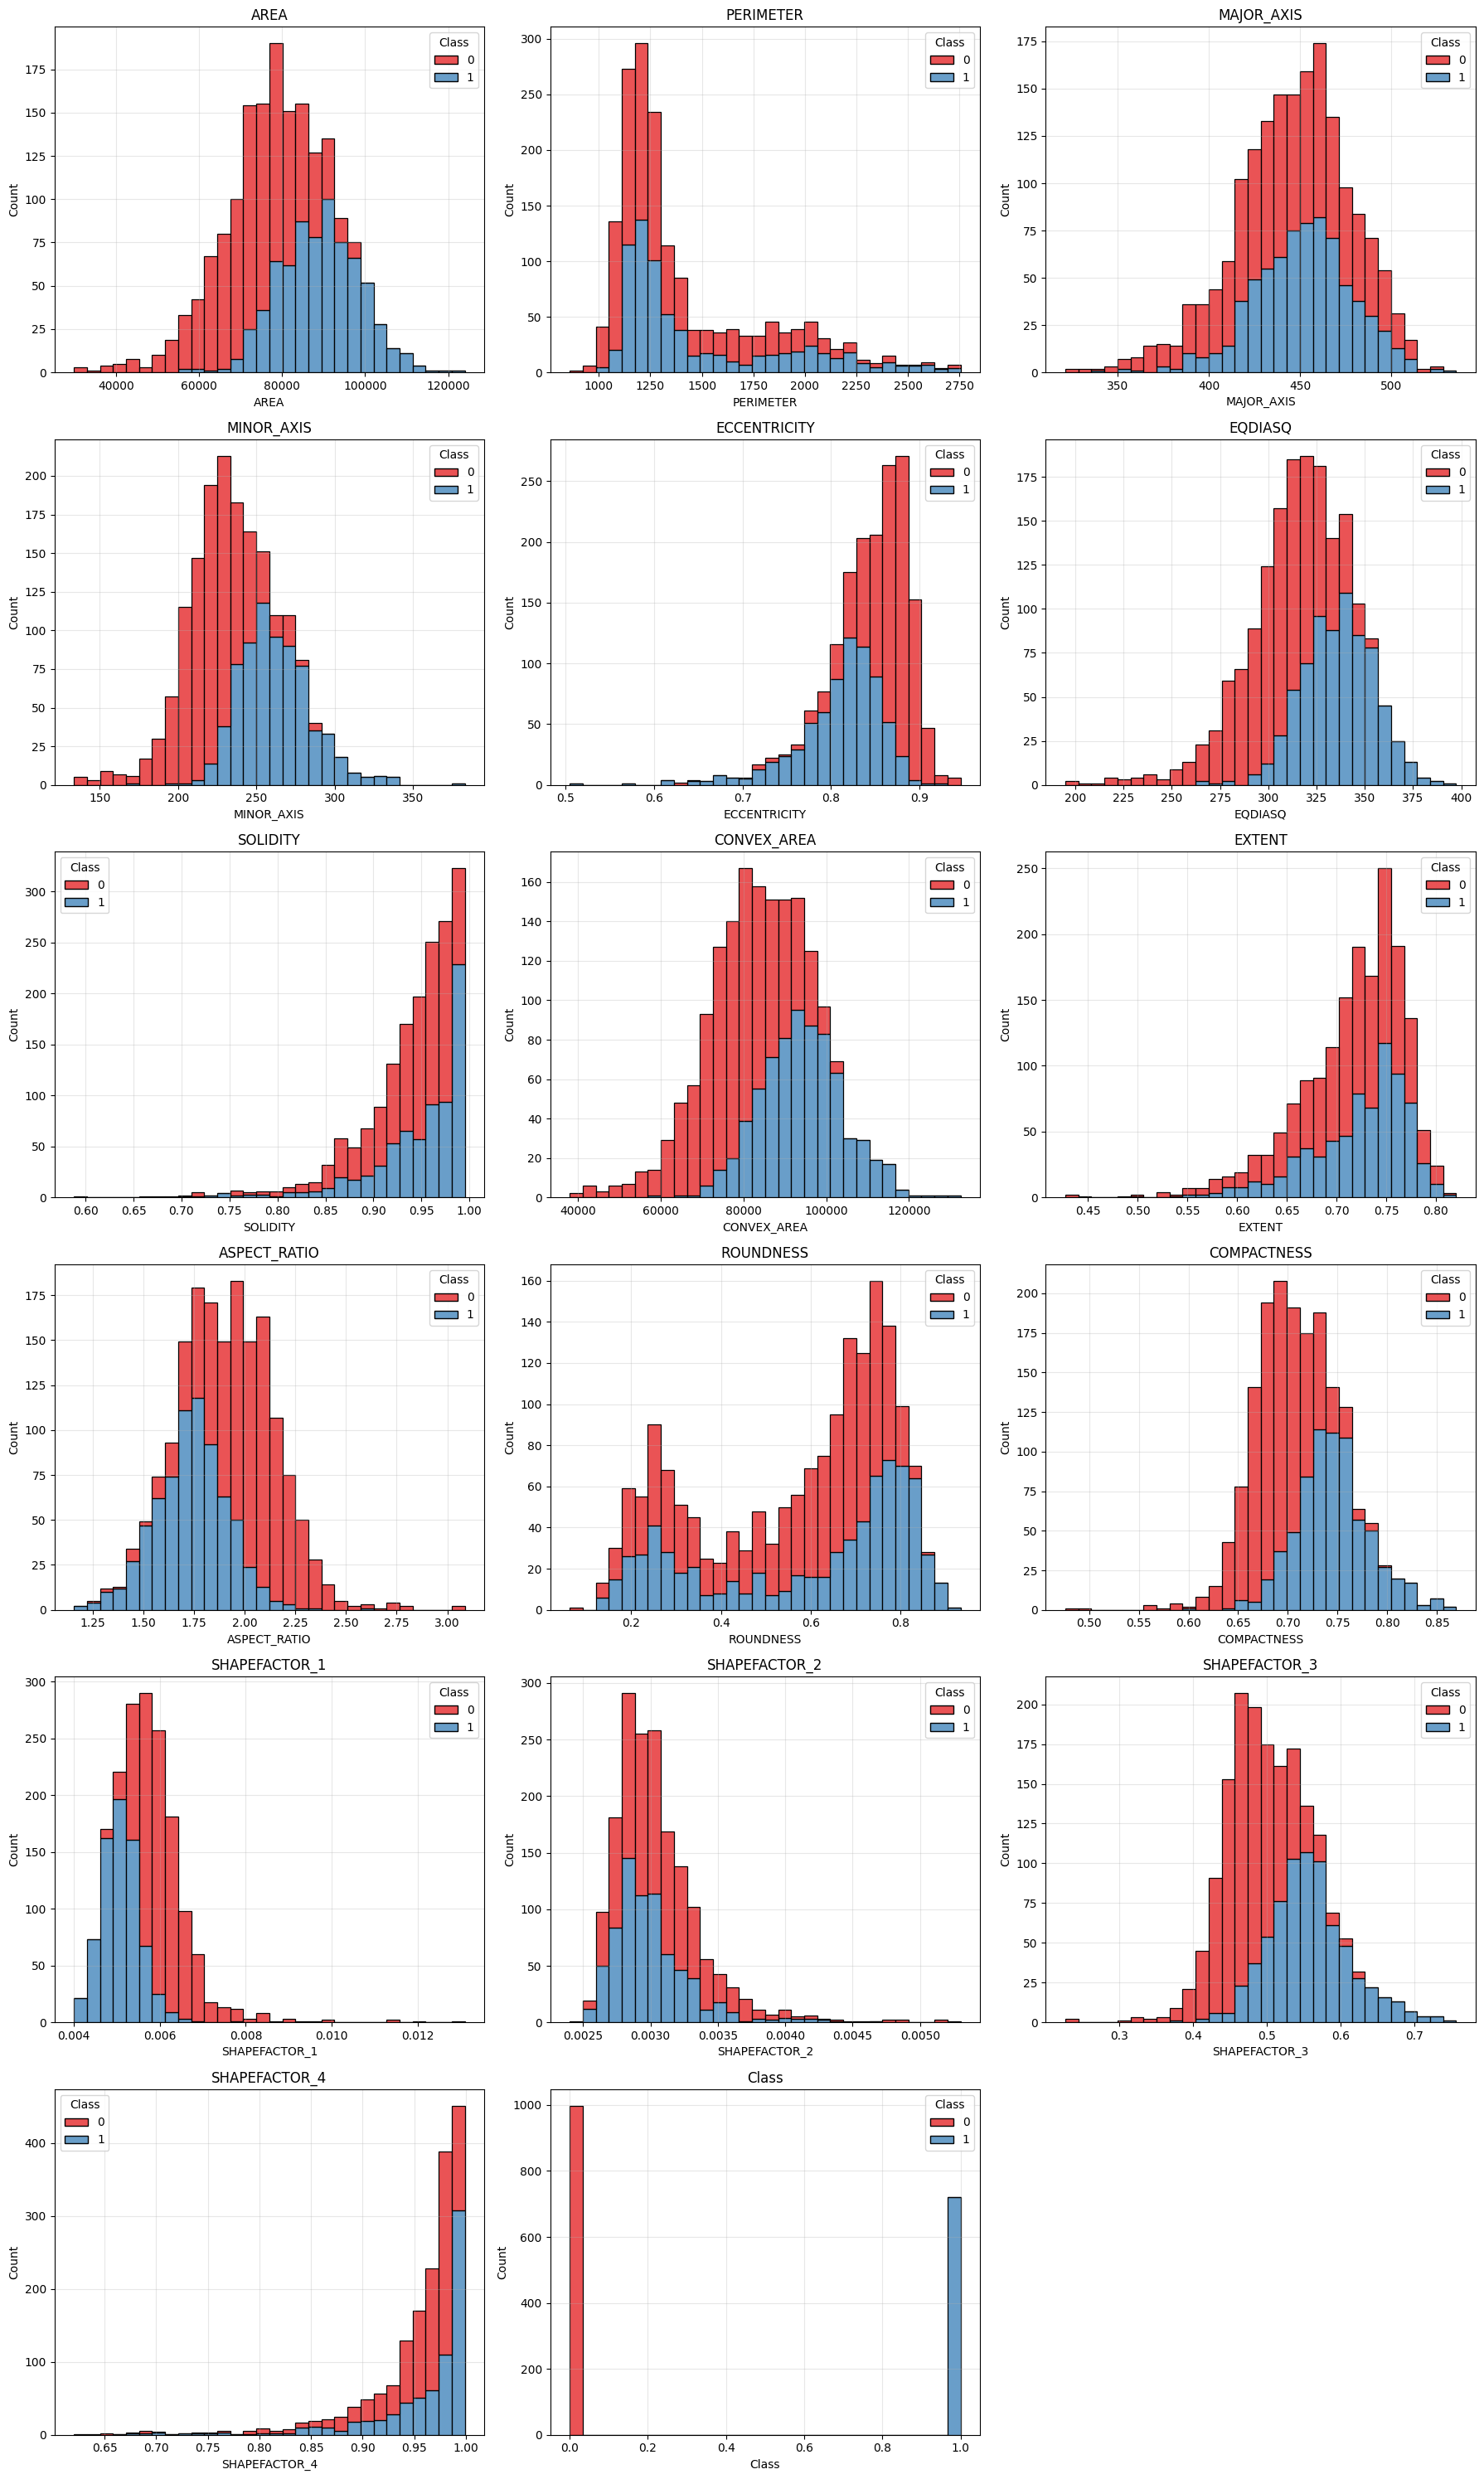

In [133]:
analyzer.plot_histograms_by_class()

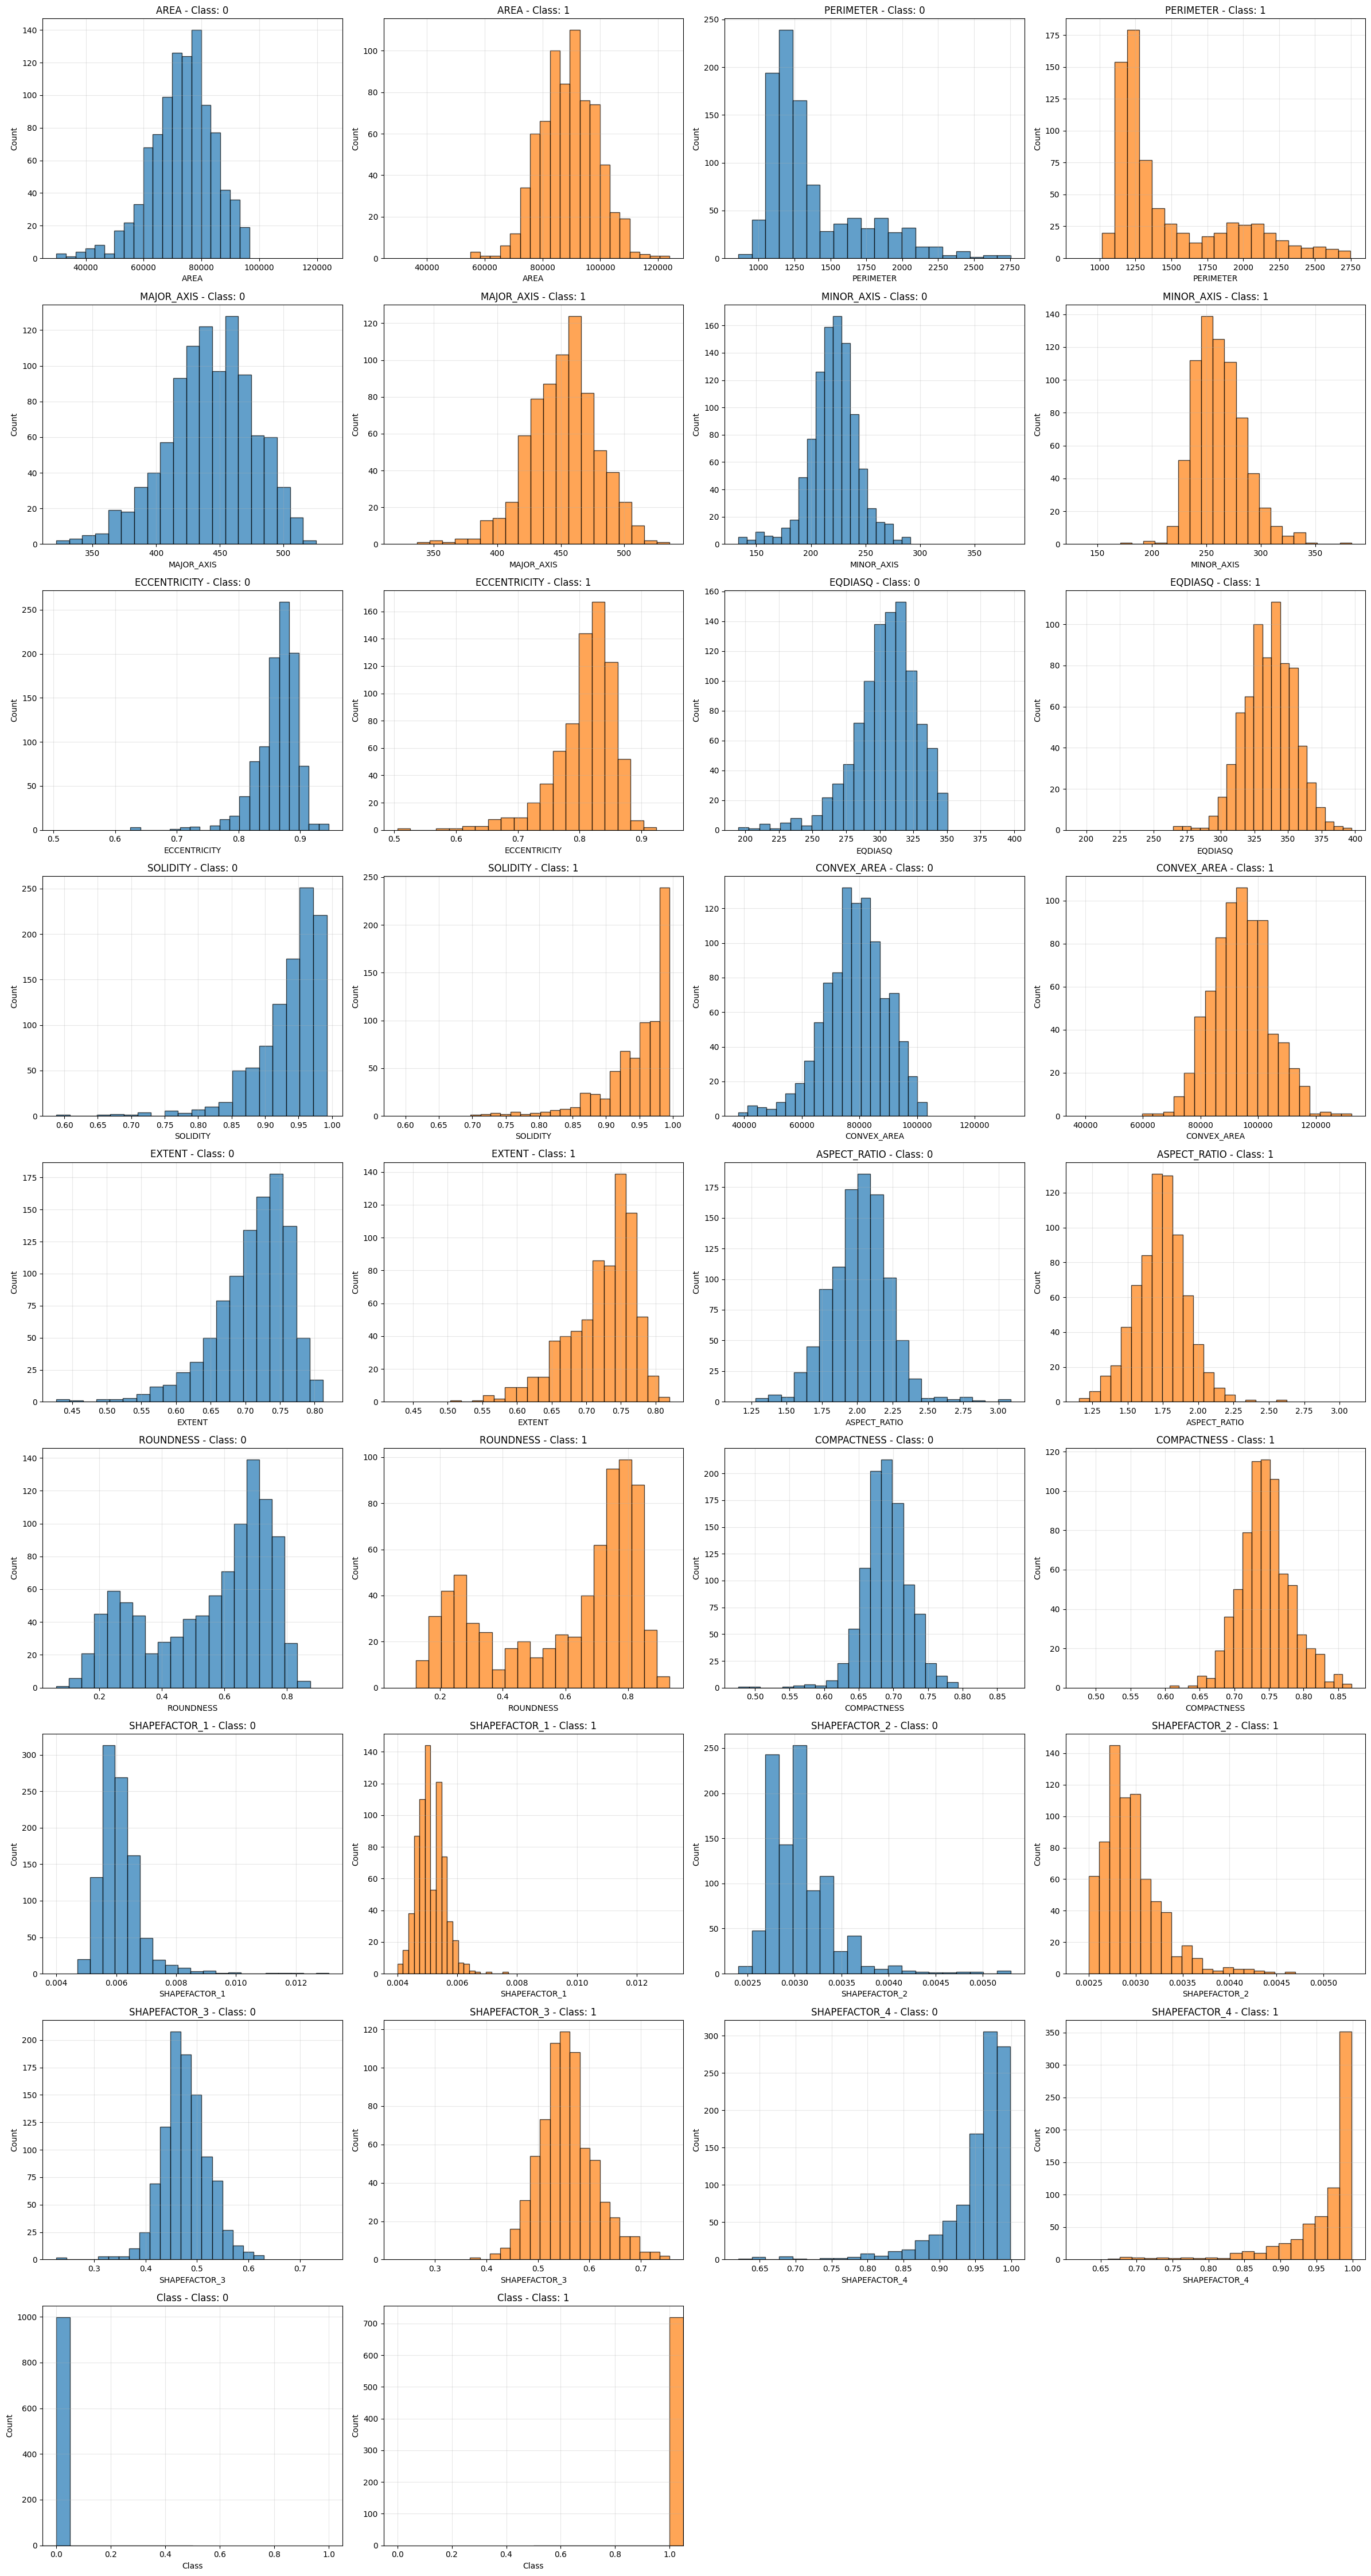

In [134]:
analyzer.plot_separate_histograms_by_class()

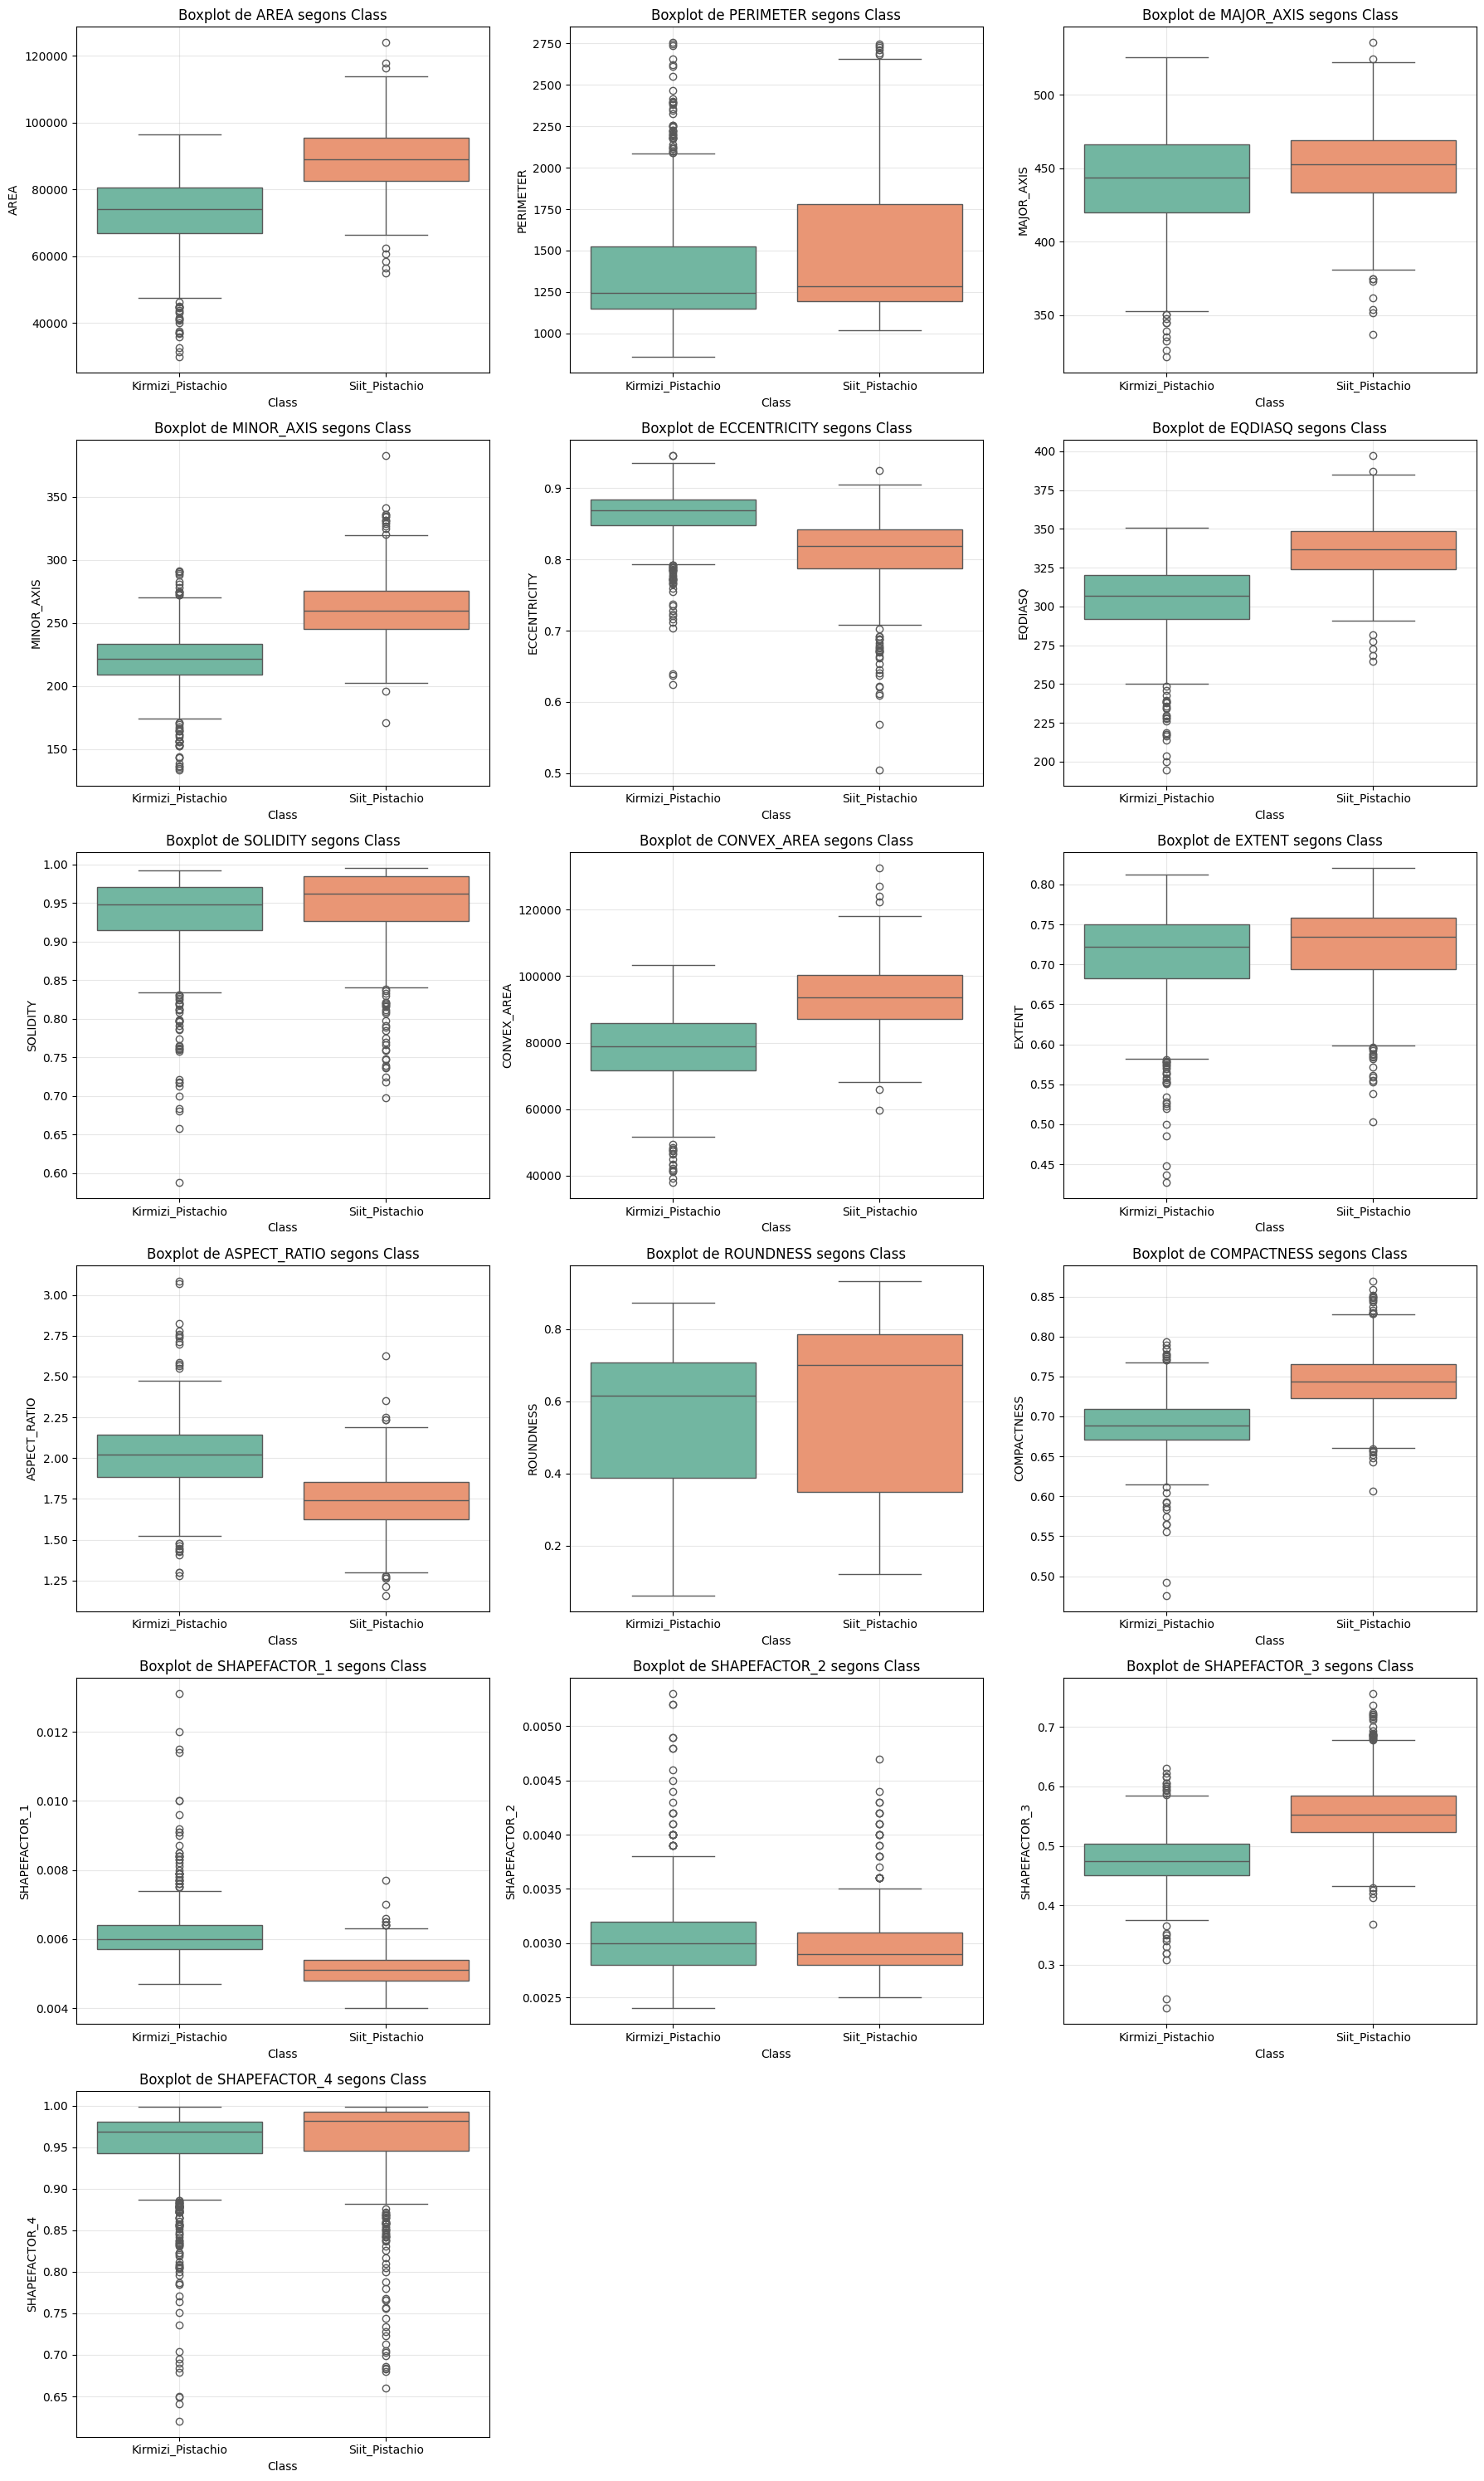

In [135]:
analyzer.plot_boxplots()

Creiem que moltes de les variables poden estar molt correlacionades, ja que moltes s'extreuen d'altres, per a comprovar això calculem el coeficient de correlació de Pearson entre tots els atributs.

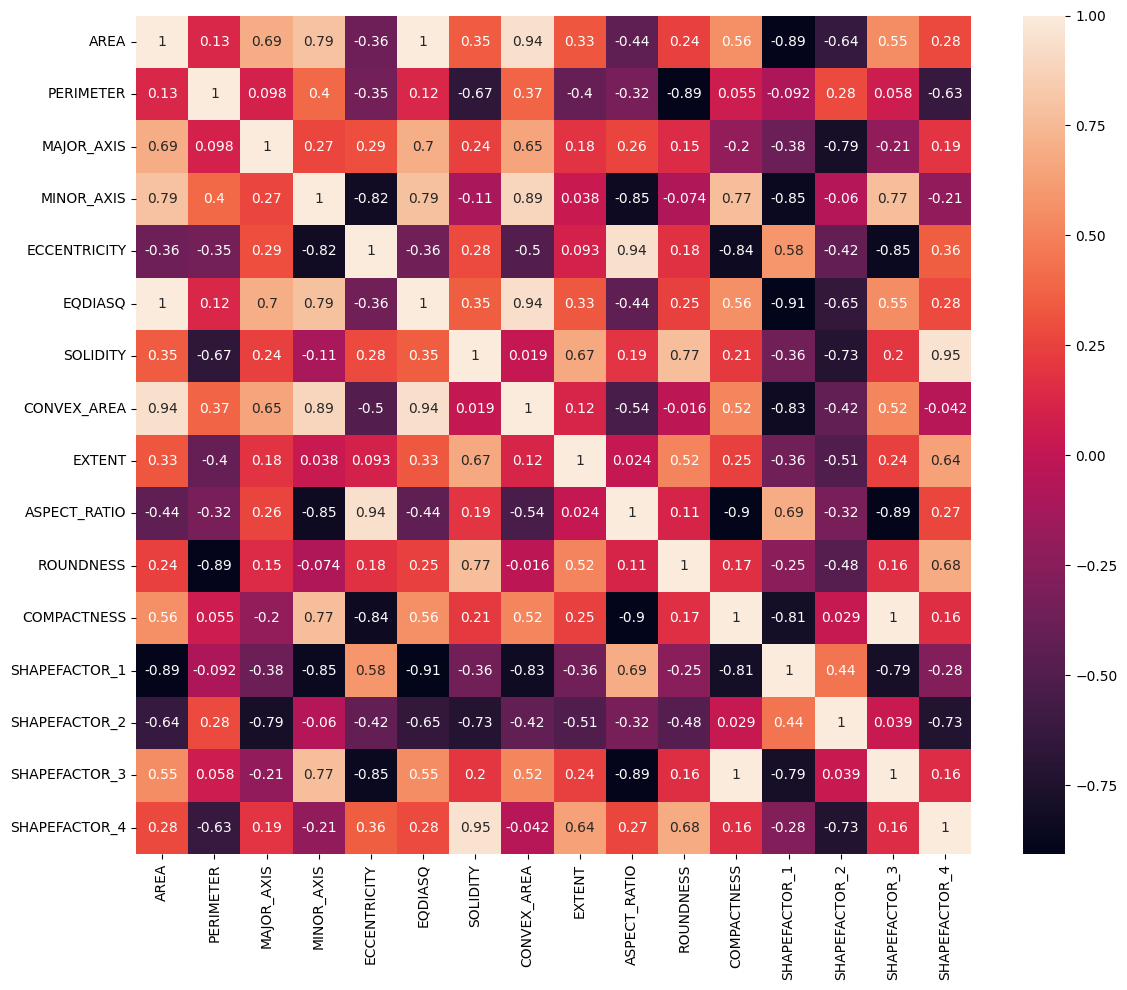

In [136]:
analyzer.plot_correlation_matrix()

Utilitzarem `LabelEncoder()` per a transformar la variable objectiu a una variable numèrica que prengui valors `0` o `1`, per tal de poder comparar la correlació amb la resta de variables.

Ara podem generar un gràfic on es vegi la correlació de cada variable amb el target Class.

C:\Users\ricar\AppData\Local\Temp\ipykernel_12800\1440113195.py:175: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


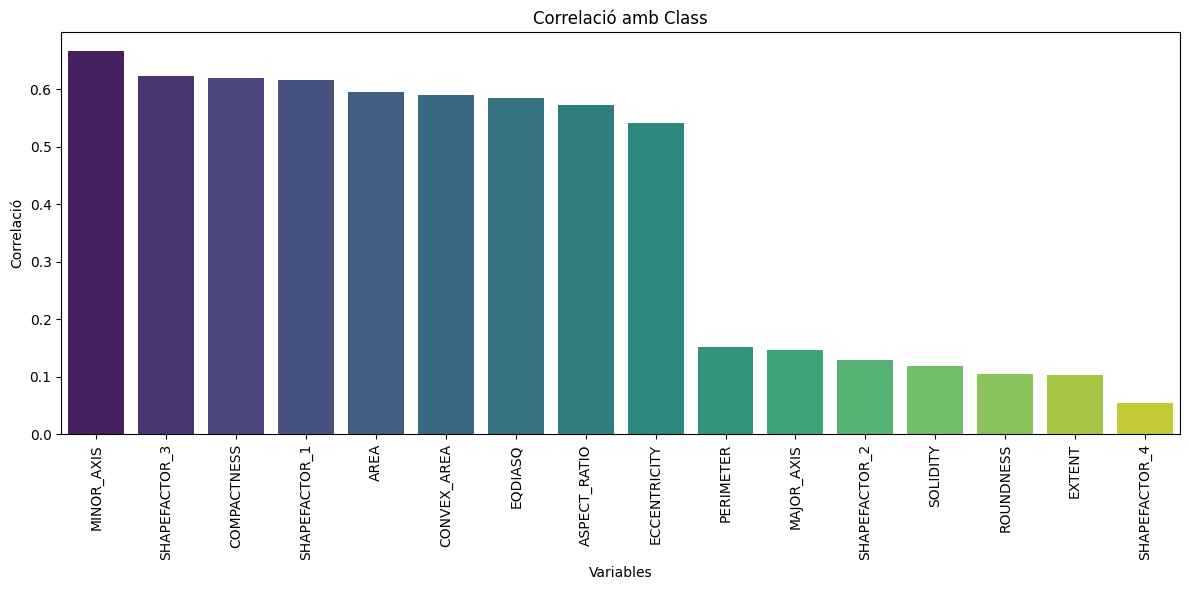

In [137]:
analyzer.plot_corr_with_target()


Decidirem de quines variables prescindir de la següent manera, triant un llindar, primer mirem quines tenen un coeficient de correlació molt alt entre elles, després, d'aquestes dues eliminem la que tingui una correlació menor amb la variable objectiu, així ens quedarem amb la que més informació ens aporta alhora de predir.

In [138]:
eliminades = analyzer.drop_highly_correlated(threshold=0.8)
print("Variables eliminades:", eliminades)

Variables eliminades: ['ECCENTRICITY', 'COMPACTNESS', 'EQDIASQ', 'AREA', 'ROUNDNESS', 'SHAPEFACTOR_4', 'ASPECT_RATIO', 'SHAPEFACTOR_1', 'CONVEX_AREA']


In [139]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# 2. Definir X (variables predictoras) y y (target)
X = selected.drop(columns=['Class'])
y = df['Class']

# Si hay variables no numéricas en X, asegúrate de transformarlas o eliminarlas
# Aquí asumimos que todas las variables predictoras son numéricas o ya están procesadas

# 3. Dividir los datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Crear el modelo
model = RandomForestClassifier(random_state=42)

# 5. Entrenar el modelo
model.fit(X_train, y_train)

# 6. Predecir sobre el conjunto de prueba
y_pred = model.predict(X_test)

# 7. Evaluar el modelo
print("Accuracy:", accuracy_score(y_test, y_pred))


NameError: name 'selected' is not defined